In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\utkar\Downloads\train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
# Check for nulls
print(df.isnull().sum())

# Fix date columns - dayfirst=True because format is DD/MM/YYYY
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Fix Sales column
df["Sales"] = df["Sales"].astype(float)

# Handle the 11 missing Postal Codes - fill with 0
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int)

print("✅ Data cleaned successfully")
print(df.dtypes)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
✅ Data cleaned successfully
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [9]:
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
total_orders = df["Order ID"].nunique()

print(f"💰 Total Sales     : ${total_sales:,.2f}")
print(f"📦 Total Orders    : {total_orders}")
print(f"📊 Average Sale    : ${avg_sales:,.2f}")

💰 Total Sales     : $2,261,536.78
📦 Total Orders    : 4922
📊 Average Sale    : $230.77


In [10]:
# Sales by Region
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("📍 Sales by Region:\n", sales_by_region)

# Sales by Category
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("\n🗂️ Sales by Category:\n", sales_by_category)

# Monthly Sales
df["Month"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Sales"].sum()
print("\n📅 Monthly Sales:\n", monthly_sales)

📍 Sales by Region:
 Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

🗂️ Sales by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

📅 Monthly Sales:
 Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06

In [16]:
# Sales by Year
df["Year"] = df["Order Date"].dt.year
sales_by_year = df.groupby("Year")["Sales"].sum().sort_values(ascending=False)

print("📅 Sales by Year:")
print(sales_by_year)

📅 Sales by Year:
Year
2018    722052.0192
2017    600192.5500
2015    479856.2081
2016    459436.0054
Name: Sales, dtype: float64


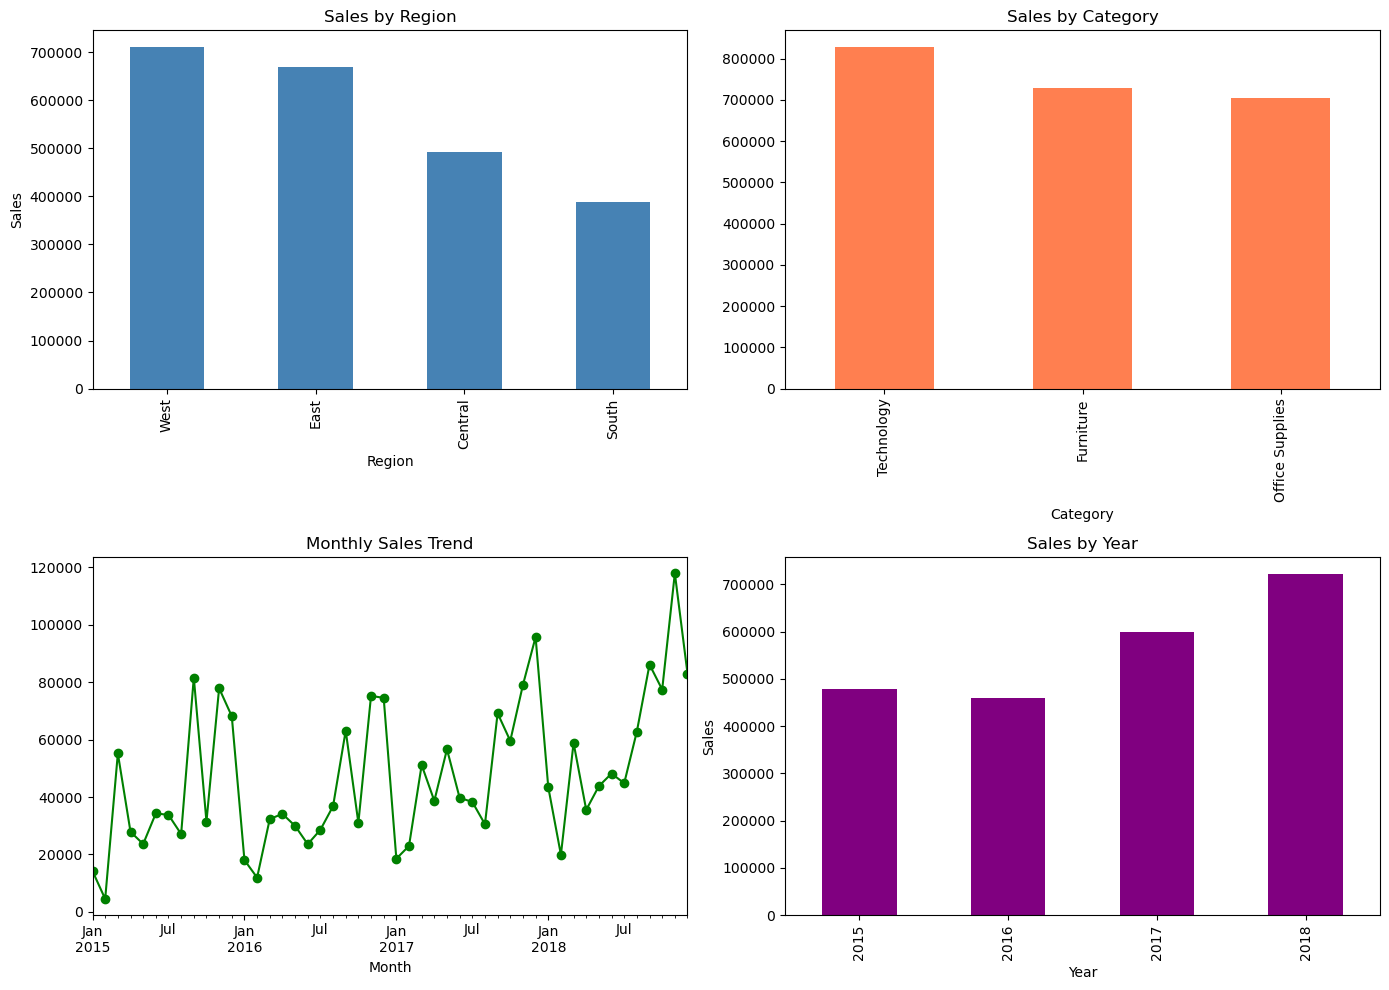

✅ Chart saved!


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Region chart
sales_by_region.plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Sales by Region")
axes[0,0].set_xlabel("Region")
axes[0,0].set_ylabel("Sales")

# Category chart
sales_by_category.plot(kind="bar", ax=axes[0,1], color="coral")
axes[0,1].set_title("Sales by Category")
axes[0,1].set_xlabel("Category")

# Monthly trend
monthly_sales.plot(kind="line", ax=axes[1,0], color="green", marker="o")
axes[1,0].set_title("Monthly Sales Trend")
axes[1,0].set_xlabel("Month")

# Yearly chart
sales_by_year.sort_index().plot(kind="bar", ax=axes[1,1], color="purple")
axes[1,1].set_title("Sales by Year")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("Sales")

plt.tight_layout()
plt.savefig(r"C:\Users\utkar\Downloads\sales_chart.png")
plt.show()
print("✅ Chart saved!")

In [24]:
from openpyxl import load_workbook
from openpyxl.chart import BarChart, LineChart, Reference

output_path = r"C:\Users\utkar\Downloads\sales_report.xlsx"

# Step 1 - Write all data sheets
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Raw Data", index=False)
    sales_by_region.to_excel(writer, sheet_name="Region Summary")
    sales_by_category.to_excel(writer, sheet_name="Category Summary")
    monthly_sales.to_excel(writer, sheet_name="Monthly Summary")
    sales_by_year.sort_index().to_excel(writer, sheet_name="Yearly Summary")

# Step 2 - Reopen and add charts
wb = load_workbook(output_path)

# --- Chart 1: Sales by Region (Bar Chart) ---
ws_region = wb["Region Summary"]
chart1 = BarChart()
chart1.title = "Sales by Region"
chart1.y_axis.title = "Sales"
chart1.x_axis.title = "Region"
data1 = Reference(ws_region, min_col=2, min_row=1, max_row=ws_region.max_row)
cats1 = Reference(ws_region, min_col=1, min_row=2, max_row=ws_region.max_row)
chart1.add_data(data1, titles_from_data=True)
chart1.set_categories(cats1)
chart1.shape = 4
chart1.width = 18
chart1.height = 12
ws_region.add_chart(chart1, "D2")

# --- Chart 2: Sales by Category (Bar Chart) ---
ws_cat = wb["Category Summary"]
chart2 = BarChart()
chart2.title = "Sales by Category"
chart2.y_axis.title = "Sales"
chart2.x_axis.title = "Category"
data2 = Reference(ws_cat, min_col=2, min_row=1, max_row=ws_cat.max_row)
cats2 = Reference(ws_cat, min_col=1, min_row=2, max_row=ws_cat.max_row)
chart2.add_data(data2, titles_from_data=True)
chart2.set_categories(cats2)
chart2.width = 18
chart2.height = 12
ws_cat.add_chart(chart2, "D2")

# --- Chart 3: Monthly Sales Trend (Line Chart) ---
ws_month = wb["Monthly Summary"]
chart3 = LineChart()
chart3.title = "Monthly Sales Trend"
chart3.y_axis.title = "Sales"
chart3.x_axis.title = "Month"
data3 = Reference(ws_month, min_col=2, min_row=1, max_row=ws_month.max_row)
chart3.add_data(data3, titles_from_data=True)
chart3.width = 25
chart3.height = 12
ws_month.add_chart(chart3, "D2")

# --- Chart 4: Sales by Year (Bar Chart) ---
ws_year = wb["Yearly Summary"]
chart4 = BarChart()
chart4.title = "Sales by Year"
chart4.y_axis.title = "Sales"
chart4.x_axis.title = "Year"
data4 = Reference(ws_year, min_col=2, min_row=1, max_row=ws_year.max_row)
cats4 = Reference(ws_year, min_col=1, min_row=2, max_row=ws_year.max_row)
chart4.add_data(data4, titles_from_data=True)
chart4.set_categories(cats4)
chart4.width = 18
chart4.height = 12
ws_year.add_chart(chart4, "D2")

# Step 3 - Save
wb.save(output_path)
print(f"✅ Excel report with charts saved to {output_path}")

✅ Excel report with charts saved to C:\Users\utkar\Downloads\sales_report.xlsx
